In [1]:
import os
os.environ['USER_AGENT'] = 'Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:47.0) Gecko/20100101 Firefox/47.0'
import langchain
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
langchain.__version__

'0.3.31'

In [2]:
with open("data/secrets/key.secret") as f:
    os.environ["OPENAI_API_KEY"] = f.read()

In [3]:
llm = init_chat_model("gpt-4o-mini", model_provider="openai")
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)

In [4]:
# Load and chunk contents of the blog
url = "https://lilianweng.github.io/posts/2023-06-23-agent/"

loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()
len(docs)

1

In [5]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
all_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='LLM Powered Autonomous Agents\n    \nDate: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng\n\n\nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refi

In [6]:
db = vector_store.add_documents(documents=all_splits)
db

['d60b1caa-89e2-48c9-b97d-18fca5293570',
 '6244b483-5665-42ad-b2d2-0621caa0aa80',
 '35304e78-7b38-4729-8c6a-bb5ac833090b',
 '7a95ff10-c3d9-42d0-92b8-59cf959080ad',
 '85699cbe-7ace-44a7-a51b-1be070311976',
 '29febc16-75de-4c9a-9a84-fdad70229ebf',
 'aab5540d-a7d2-4e94-a8fc-a589553255bf',
 '90d70d82-a1bd-41e1-8583-8bf1b152121d',
 '15d3e9a7-3177-4282-abee-d416a9de7535',
 '4c50df4c-4207-4e86-b419-01bdef1655aa',
 'bfda34ed-f4f2-45f8-a565-293082ef9c81',
 '3c0e86a5-3a06-4fad-8f07-8f81d993e5a4',
 'f004cea8-feb6-4db1-bc1e-14c03aec3e59',
 '491efc75-6aa9-4da6-92f2-1c8c752a2e71',
 '40d5bb9e-e6e4-448d-8ac4-089c821e23cf',
 '4861d314-5606-421b-ac19-4078679cdda8',
 '1a4a2298-634b-447f-8c47-894cc6caaec7',
 '0128c51a-0d4e-4c00-ba83-5cc7d27c270f',
 '034a610e-372a-4830-8eb6-fc090e45e24f',
 '1f19d6da-23ae-4daf-93a4-ba238fdd9747',
 'bca156e7-6919-4f77-a7c3-b8e78d1b9b14',
 'af9403bd-8a2f-4558-9254-135099ae7cf4',
 '188a133e-de7e-4949-8929-c6ce2ab14755',
 '91043e60-70e5-4f66-9ec1-47f88d7d498c',
 'c7d68e78-45b4-

rml.rag-prompt : https://smith.langchain.com/hub/rlm/rag-prompt?_gl=1*11dcy42*_gcl_au*MTAxOTgzMzI4My4xNzYwMzQ5ODk5*_ga*MTI3MDkwMDAzMS4xNzYwMzQ5ODk5*_ga_47WX3HKKY2*czE3NjA2MzYyOTEkbzgkZzEkdDE3NjA2MzczMzkkajI0JGwwJGgw

In [7]:
prompt = hub.pull("rlm/rag-prompt")
prompt

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})])

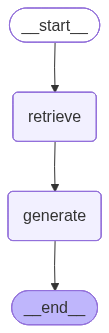

In [8]:
class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}


def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content})
    response = llm.invoke(messages)
    return {"answer": response.content}


# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()
graph

In [9]:
response = graph.invoke({"question": "What is Task Decomposition?"})
response

{'question': 'What is Task Decomposition?',
 'context': [Document(id='7a95ff10-c3d9-42d0-92b8-59cf959080ad', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back into natural language. Essentially, the planning step is outso

In [10]:
response["answer"]

'Task decomposition is the process of breaking a complicated task into smaller, manageable steps or subgoals. It can be achieved through various methods, such as prompting large language models (LLMs) to outline steps, using task-specific instructions, or incorporating human inputs. Additionally, techniques like Chain of Thought (CoT) or Tree of Thoughts enhance this process by exploring reasoning possibilities at each step.'